In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

In [2]:
df = pd.read_csv('data/ekg1.txt', sep=' ', header=None)
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,106,335,228,-227,-59,291,-392,-45,443,372,908,395
1,106,335,228,-227,-59,291,-392,-45,443,372,908,395
2,106,325,219,-219,-60,284,492,837,239,372,908,405
3,86,306,219,-214,-55,274,487,832,240,404,179,-63
4,96,320,224,-195,-65,264,492,842,244,404,174,-62
5,106,325,219,-207,-62,274,492,832,235,414,189,-52
6,96,335,238,-214,-55,274,492,836,235,399,174,-67
7,96,325,228,-214,-70,288,492,831,230,399,174,-62
8,116,335,219,-209,-65,279,487,825,230,394,174,-67
9,101,335,233,-224,-50,279,492,835,240,394,164,-86


In [3]:
df.size

60000

In [4]:
def plot_signals(df, signal_start, signal_end, signal_frequency, y_scale):
    plt.close('all')
    fig, axes = plt.subplots(12, 1, figsize=(16, 36), sharex=True)

    signal_start *= signal_frequency
    signal_end *= signal_frequency
    signal_start = int(signal_start)
    signal_end = int(signal_end)

    for i in range(12):
        sns.lineplot(data=df[signal_start:signal_end], x=df[signal_start:signal_end].index, y=df.columns[i], ax=axes[i])
        axes[i].set_ylim(-y_scale, y_scale)
        axes[i].set_title(f"Signal {i}")

    plt.tight_layout()
    plt.show()

In [5]:
def save_signals(df, signal_start, signal_end, signal_frequency, filename):
    signal_start *= signal_frequency
    signal_end *= signal_frequency
    signal_start = int(signal_start)
    signal_end = int(signal_end)
    df[signal_start:signal_end].to_csv(filename, index=False, sep=' ', header=None)

In [6]:

out = widgets.Output() 


title_label = widgets.HTML(value="")

start_input = widgets.BoundedFloatText(
    value=0,
    min=0,
    max=5,
    step=0.1,
    description='Start:',
    layout=widgets.Layout(width='200px')
)

end_input = widgets.BoundedFloatText(
    value=5,
    min=0,
    max=5,
    step=0.1,
    description='End:',
    layout=widgets.Layout(width='200px')
)

freq_input = widgets.BoundedIntText(
    value=1000,
    min=0,
    max=10000,
    step=1,
    description='Frequency:',
    layout=widgets.Layout(width='200px')
)
y_scale_input = widgets.BoundedIntText(
    value=1000,
    min=0,
    max=10000,
    step=1,
    description='Y axis scale:',
    layout=widgets.Layout(width='200px')
)
filename_input = widgets.Text(
    value='ekg_signals.txt',
    description='Filename:',
    layout=widgets.Layout(width='200px')
)

btn_update = widgets.Button(description='Update', button_style='info')
btn_save = widgets.Button(description='Save', button_style='info')


def update_plot():

    with out:
        clear_output(wait=True) 
        plot_signals(df, start_input.value, end_input.value, freq_input.value, y_scale_input.value)


def btn_update_clicked(b):
    update_plot()

def btn_save_clicked(b):
    save_signals(df, start_input.value, end_input.value, freq_input.value, filename_input.value)
    print("Signals saved to:", "results/" + filename_input.value)


btn_update.on_click(btn_update_clicked)
btn_save.on_click(btn_save_clicked)


controls_box = widgets.HBox([btn_update, btn_save, freq_input, start_input, end_input, y_scale_input, filename_input])

display(title_label, controls_box, out)


update_plot()

HTML(value='')

Output()

<Axes: >

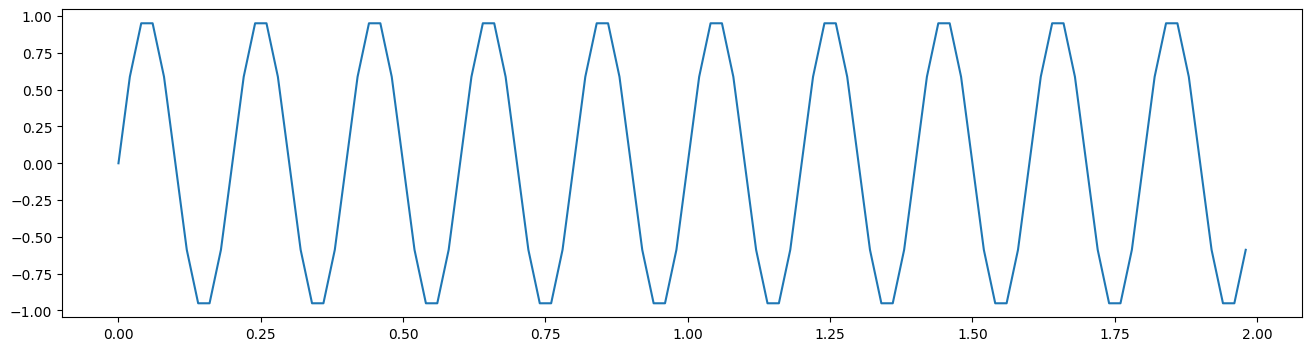

In [7]:
freq = 50
time = np.arange(0, 65536, 1/freq)
signal = np.sin(2 * np.pi * 5 * time)
plt.figure(figsize=(16, 4))
sns.lineplot(x=time[:100], y=signal[:100])


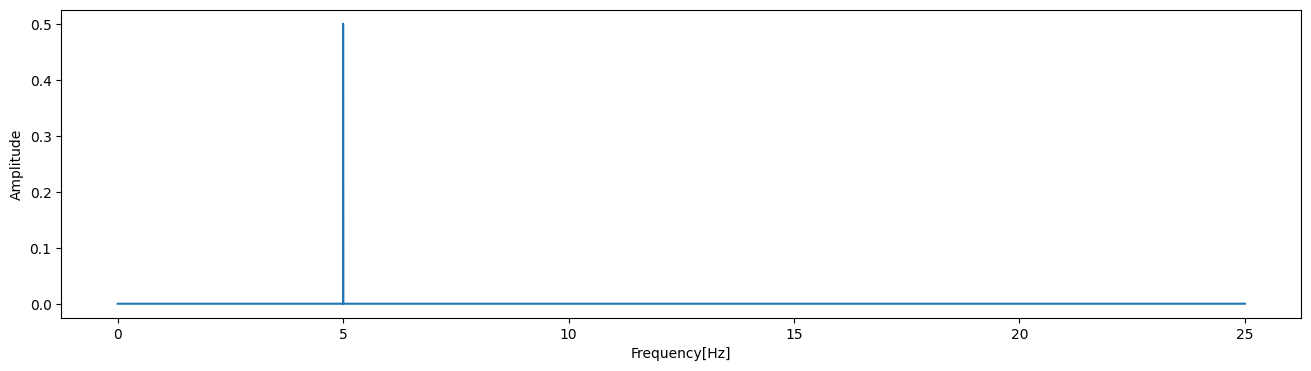

In [8]:
#DDF
n = len(signal)
fft_res = np.fft.fft(signal)
amplit = np.abs(fft_res)/n
freqs = np.fft.fftfreq(n, d=1/freq)
range1 = (freqs >= 0) & (freqs <= freq/2)

plt.figure(figsize=(16,4))
plt.plot(freqs[range1], amplit[range1])
plt.xlabel("Frequency[Hz]")
plt.ylabel("Amplitude")
plt.show()

In [9]:
def generate_mixed_signals(freqs, amplitudes, fs, N):
    time = np.arange(N) / fs
    signal = sum(a * np.sin(2 * np.pi * f * time) for f, a in zip(freqs, amplitudes))
    return time, signal

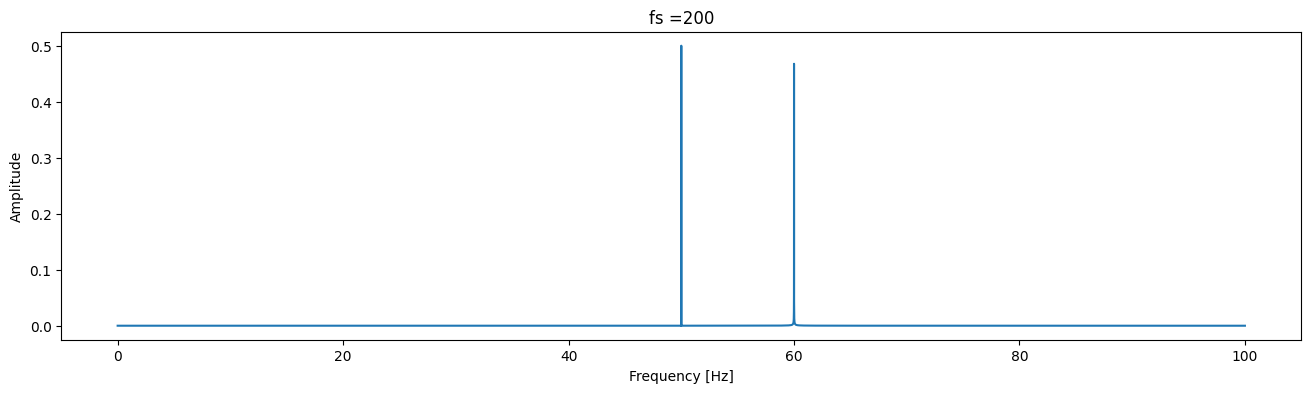

In [10]:
def plot_spectrum(signal, fs):
    N = len(signal)
    fft_result = np.fft.fft(signal)
    amplitudes = np.abs(fft_result) / N
    frequencies = np.fft.fftfreq(N, d=1/fs)
    mask = (frequencies >= 0) & (frequencies <= fs/2)
    plt.figure(figsize=(16, 4))
    plt.plot(frequencies[mask], amplitudes[mask])
    plt.title(f'fs ={ fs}')
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude")
    plt.show()

time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=200, N=65536)
plot_spectrum(signal, fs=200)

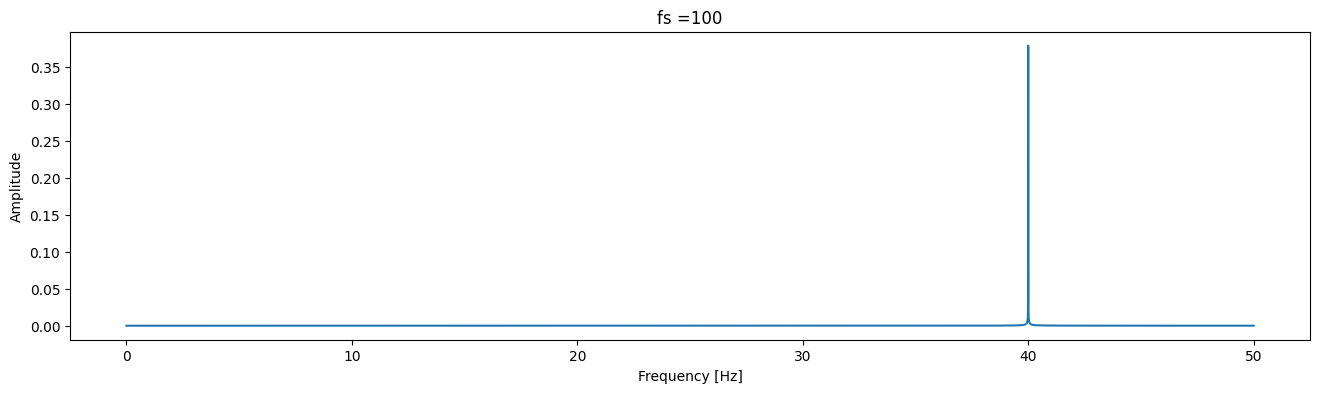

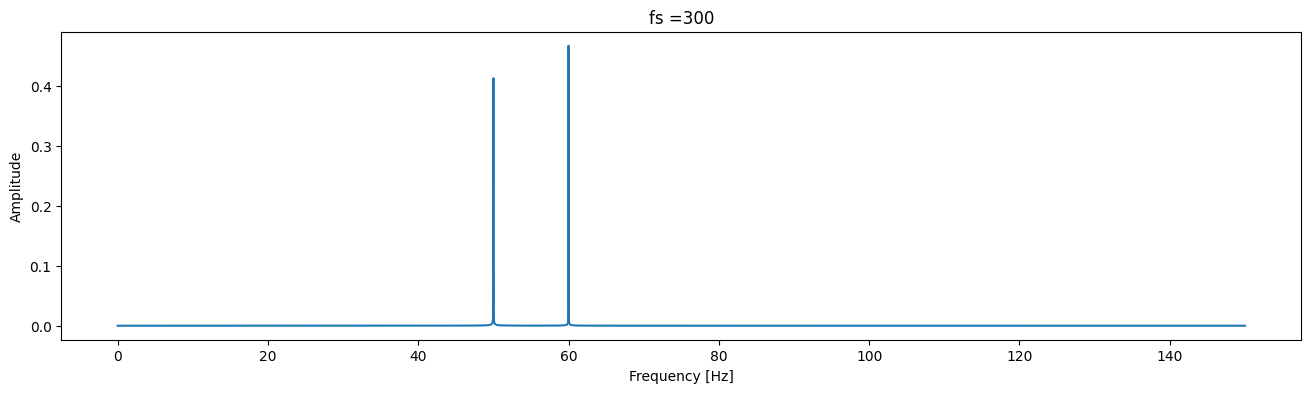

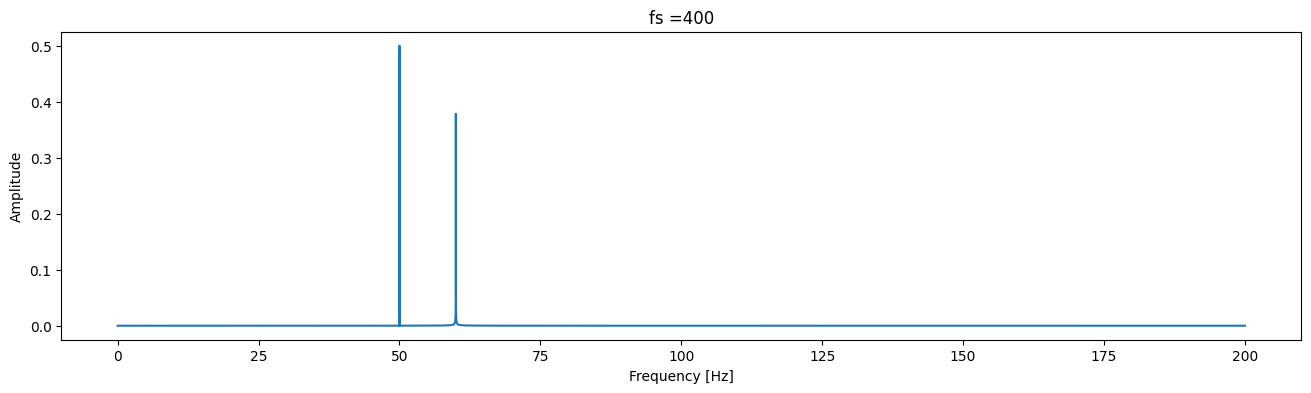

In [11]:
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=100, N=65536)
plot_spectrum(signal, fs=100)
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=300, N=65536)
plot_spectrum(signal, fs=300)
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=400, N=65536)
plot_spectrum(signal, fs=400)

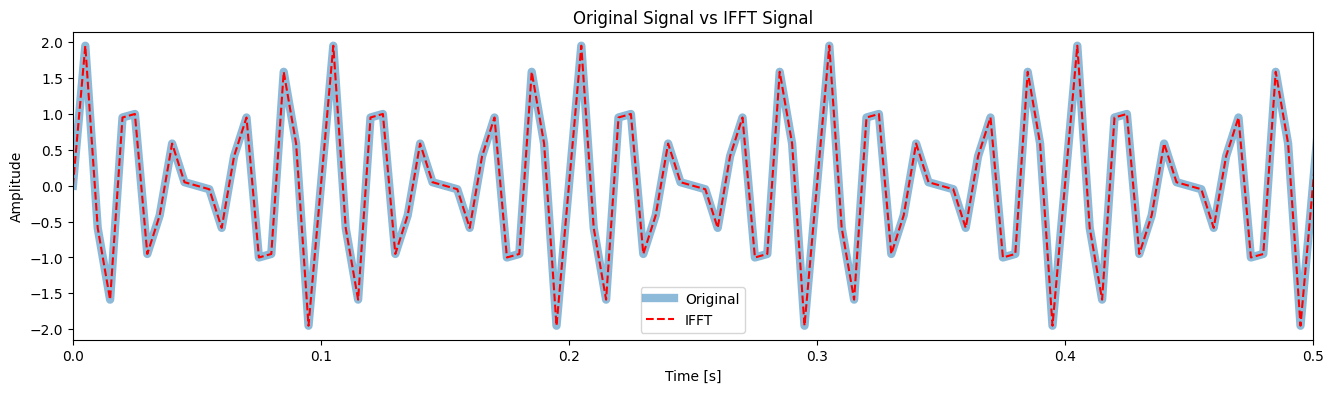

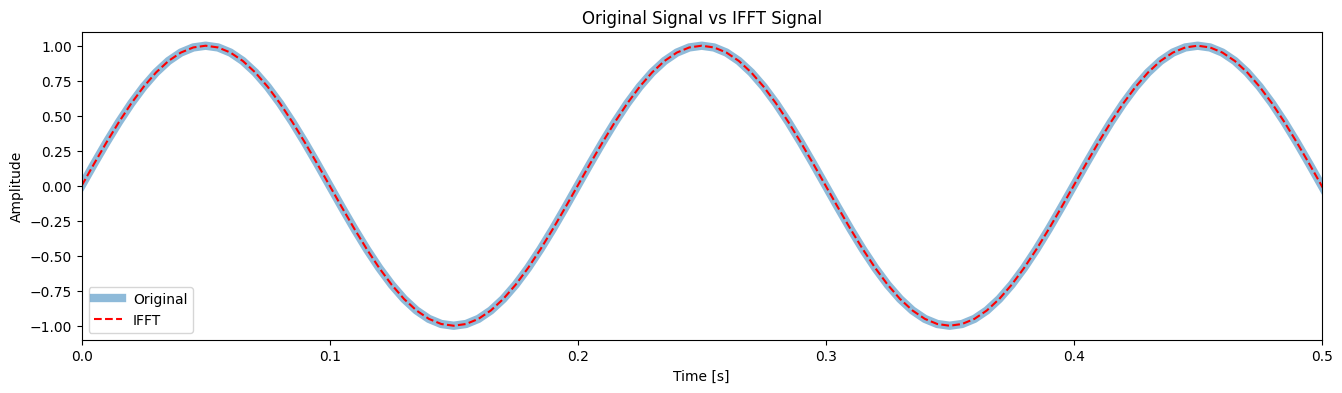

In [12]:
def plot_ifft(time, signal):
    N = len(signal)
    
    fft_result = np.fft.fft(signal)
    ifft_result = np.fft.ifft(fft_result)
    ifft_real = np.real(ifft_result)    
    

    plt.figure(figsize=(16, 4))
    
    plt.plot(time, signal, label='Original', linewidth=6, alpha=0.5) 
    plt.plot(time, ifft_real, 'r--', label='IFFT') 
    
    plt.xlim(0, 0.5)
    plt.title("Original Signal vs IFFT Signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()
time, signal1 = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=200, N=65536)
plot_ifft(time, signal1)
signal_sin=np.sin(2 * np.pi * 5 * time)
plot_ifft(time, signal=signal_sin)

In [13]:
df_ekg = pd.read_csv('data/ekg100.txt', sep='\s+', header=None)
df_ekg.columns = ['Amplitude'] 
df_ekg.head(10)

,Amplitude
0,-0.145
1,-0.145
2,-0.145
3,-0.145
4,-0.145
5,-0.145
6,-0.145
7,-0.145
8,-0.120
9,-0.135


<Axes: >

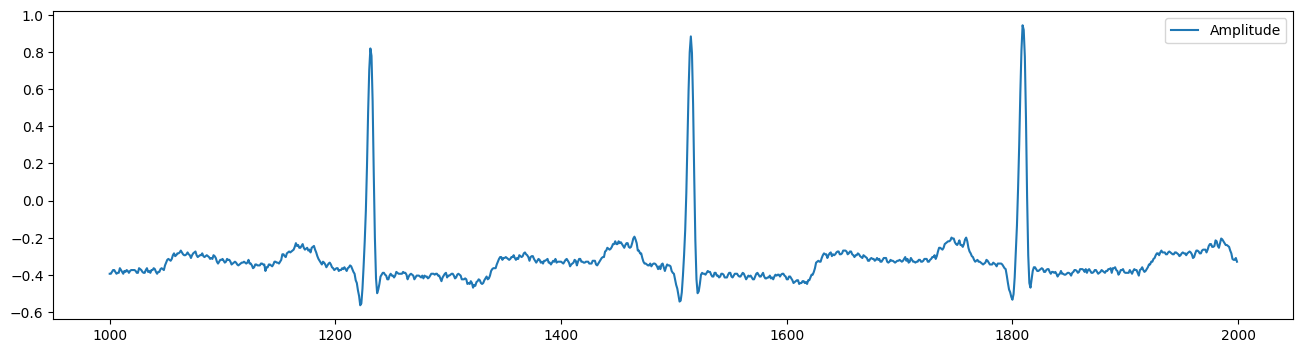

In [14]:
plt.figure(figsize=(16,4))
sns.lineplot(df_ekg[1000:2000])

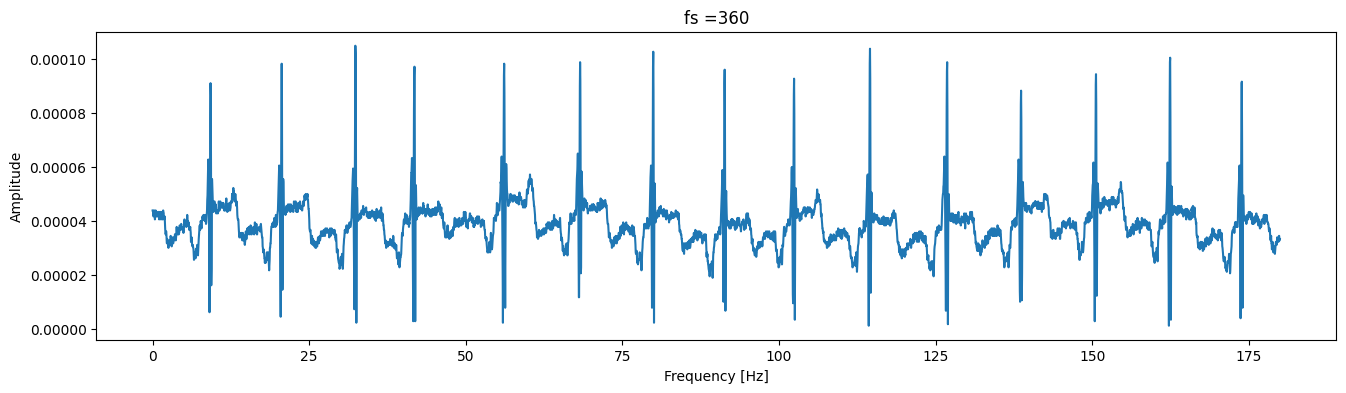

In [15]:
signal_ekg = df_ekg[1000:10000].to_numpy()
plot_spectrum(signal_ekg,360)

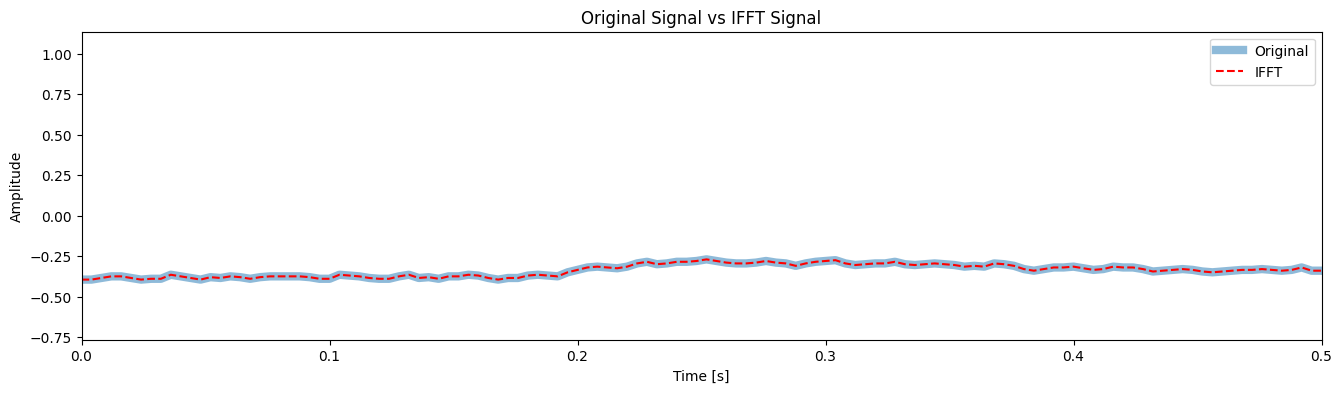

In [16]:
fs_ekg = 250 
time_ekg = np.arange(len(signal_ekg)) / fs_ekg

plot_ifft(time_ekg, signal_ekg)

In [17]:
from scipy.signal import butter, filtfilt

In [18]:
df_ekg_noise = pd.read_csv('data/ekg_noise.txt', sep='\s+', header=None)
df_ekg_noise.columns = ['time','signal']
df_ekg_noise.head(10)

,time,signal
0,0.000000,-0.325000
1,0.002778,-0.273038
2,0.005556,-0.268038
3,0.008333,-0.320000
4,0.011111,-0.391962
5,0.013889,-0.396962
6,0.016667,-0.340000
7,0.019444,-0.263038
8,0.022222,-0.258038
9,0.025000,-0.315000


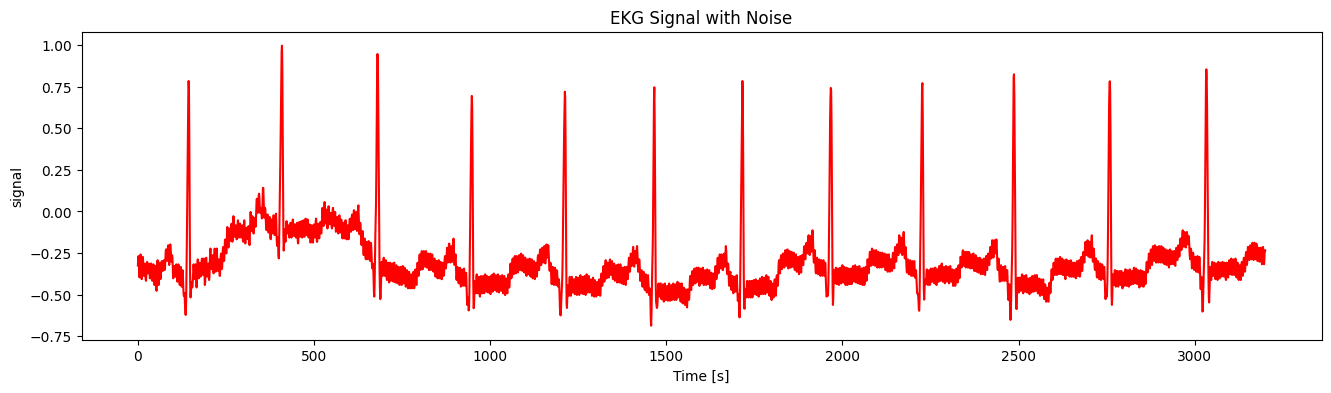

In [19]:
plt.figure(figsize=(16,4))
sns.lineplot(df_ekg_noise['signal'][0:10000], color='red')
plt.title("EKG Signal with Noise")
plt.xlabel("Time [s]")  
plt.show()

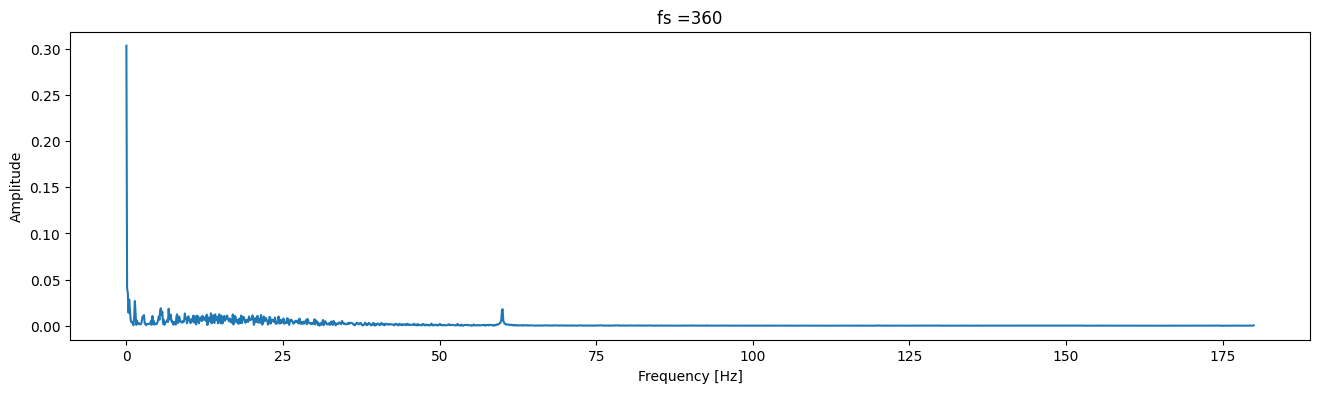

In [20]:
signal_ekg_noise = df_ekg_noise['signal'].to_numpy()
plot_spectrum(signal_ekg_noise, fs=360)

In [21]:
def butter_lowpass_filter(data, cutoff=60, fs=360, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

def butter_highpass_filter(data, cutoff=5, fs=360, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, data)

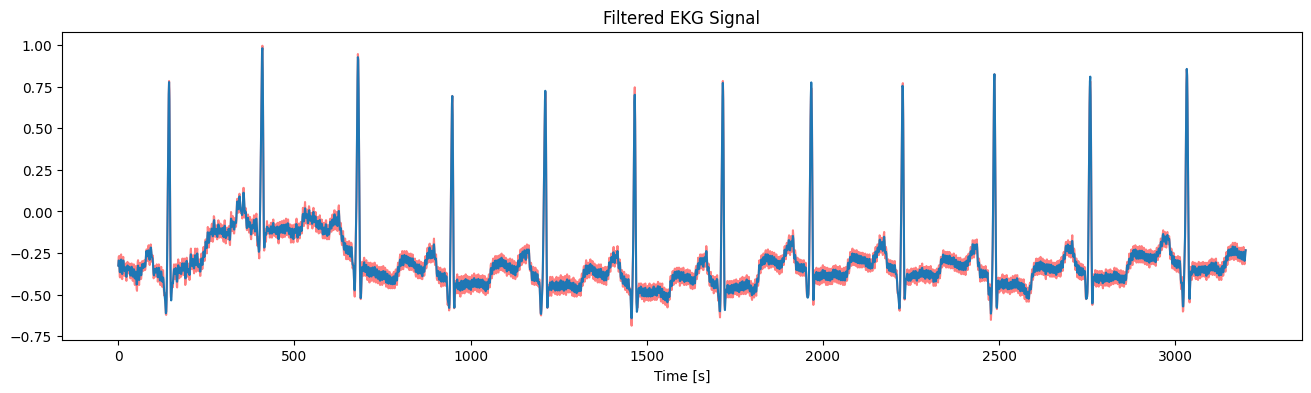

In [22]:
filtered_low = butter_lowpass_filter(signal_ekg_noise, cutoff=60, fs=360, order=4)

plt.figure(figsize=(16,4))
sns.lineplot(signal_ekg_noise, color='red', alpha=0.5)
sns.lineplot(filtered_low)
plt.title("Filtered EKG Signal")
plt.xlabel("Time [s]")
plt.show()

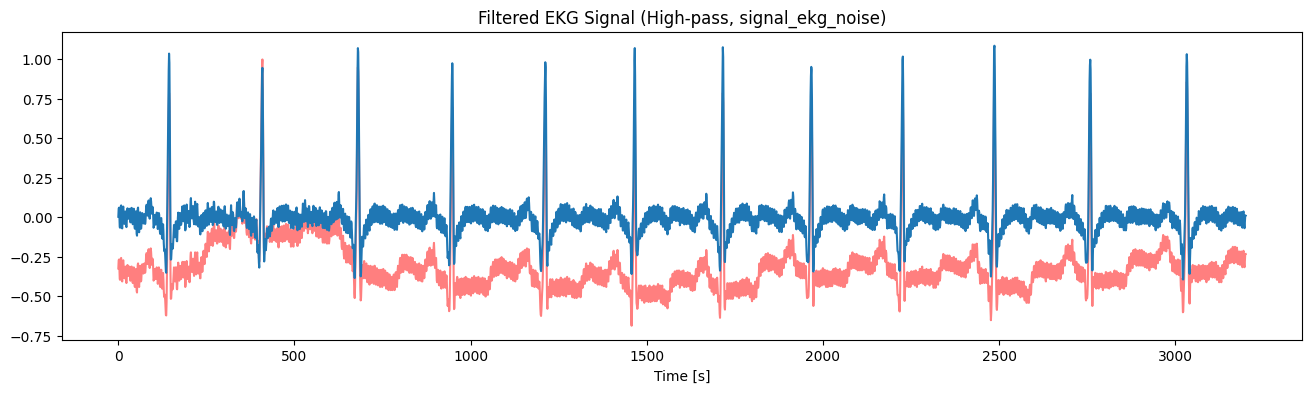

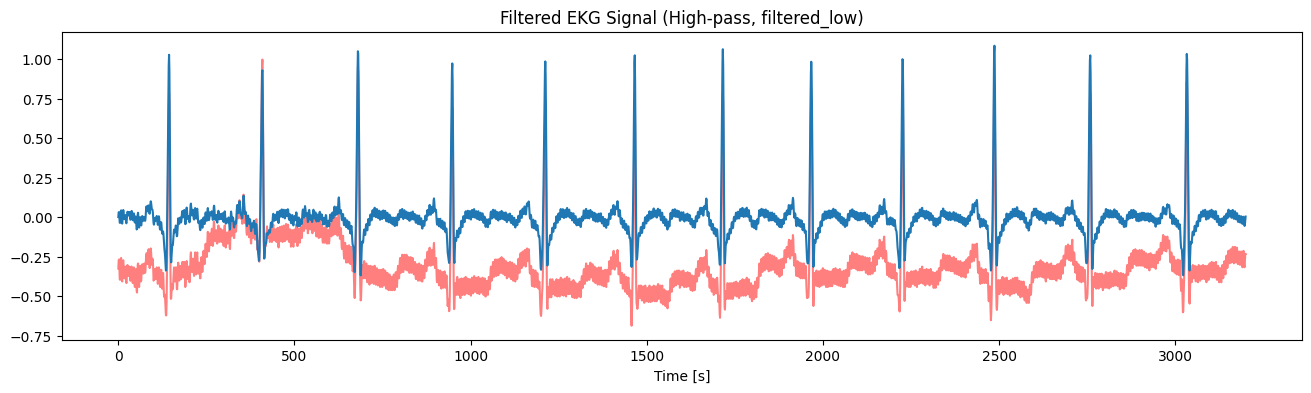

In [23]:
filtered_high = butter_highpass_filter(signal_ekg_noise, cutoff=5, fs=360, order=4)

plt.figure(figsize=(16,4))
sns.lineplot(signal_ekg_noise, color='red', alpha=0.5)
sns.lineplot(filtered_high)
plt.title("Filtered EKG Signal (High-pass, signal_ekg_noise)")
plt.xlabel("Time [s]")
plt.show()

filtered_high = butter_highpass_filter(filtered_low, cutoff=5, fs=360, order=4)

plt.figure(figsize=(16,4))
sns.lineplot(signal_ekg_noise, color='red', alpha=0.5)
sns.lineplot(filtered_high)
plt.title("Filtered EKG Signal (High-pass, filtered_low)")
plt.xlabel("Time [s]")
plt.show()


In [24]:

def butter_band_filter(data, lowcut=5, highcut=30, fs=360, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

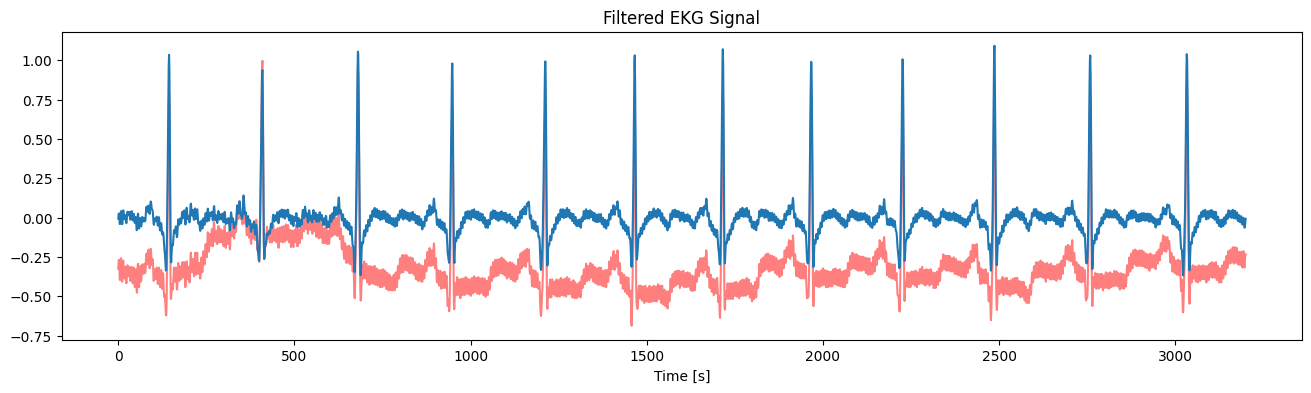

In [25]:
filtered_band = butter_band_filter(signal_ekg_noise, lowcut=5, highcut=60, fs=360, order=4)

plt.figure(figsize=(16,4))
sns.lineplot(signal_ekg_noise, color='red', alpha=0.5)
sns.lineplot(filtered_band)
plt.title("Filtered EKG Signal")
plt.xlabel("Time [s]")
plt.show()